In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Covertype (on prend un sous-échantillon pour la rapidité)
data = fetch_covtype()
X = data.data[:2000]
y = data.target[:2000]

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train,
    feature_names=[f'feature_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=X_train.shape[1],
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Explication locale (feature, poids):
[('feature_0', -1.036756601110969), ('feature_5', 0.5351797915536799), ('feature_8', 0.3982759264391066), ('feature_3', 0.2742061847750981), ('feature_7', 0.12810071316949867), ('feature_25', 0.1133123878672348), ('feature_1', 0.09357478632478627), ('feature_4', 0.0897551687035858), ('feature_49', -0.05877777777777776), ('feature_43', -0.03845454545454549), ('feature_2', 0.03828401842664775), ('feature_6', -0.02707083333333324), ('feature_36', 0.0), ('feature_10', 0.0), ('feature_37', 0.0), ('feature_18', 0.0), ('feature_33', 0.0), ('feature_12', 0.0), ('feature_31', 0.0), ('feature_29', 0.0), ('feature_13', 0.0), ('feature_22', 0.0), ('feature_9', 0.0), ('feature_14', 0.0), ('feature_17', 0.0), ('feature_41', 0.0), ('feature_53', 0.0), ('feature_52', 0.0), ('feature_46', 0.0), ('feature_30', 0.0), ('feature_35', 0.0), ('feature_45', 0.0), ('feature_24', 0.0), ('feature

In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=[f'feature_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in sorted(set(y))],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=10
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('feature_0', -0.07603612059393233), ('feature_3', 0.042518352240722215), ('feature_8', 0.0268570630425327), ('feature_7', 0.016246072245466717), ('feature_1', 0.015319643283841082), ('feature_6', -0.01188978872971176), ('feature_25', 0.007511742183508325), ('feature_36', -0.006399223998947166), ('feature_42', 0.004974846772823235), ('feature_43', -0.003655098448994492)]


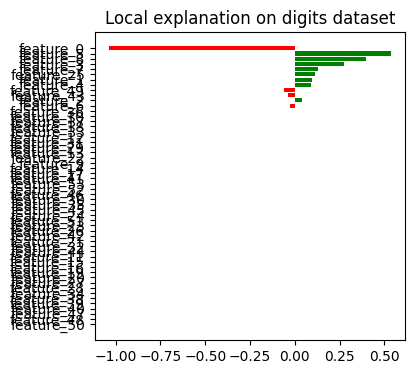

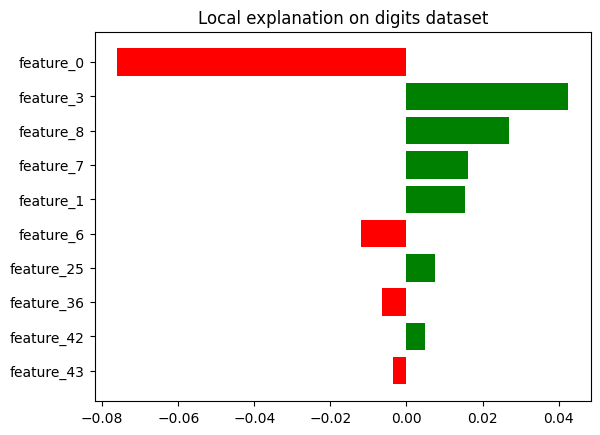

In [4]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on digits dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on digits dataset")
plt.show()